# Notebook Downloads Data from FRED & YF
## Combines into single dataframe and saves
### Authors Andy Jiang & Collin McDevitt
### Date 02/21/2026

In [1]:
%pip install neuralforecast yfinance matplotlib pandas numpy statsmodels pmdarima scikit-learn darts setuptools
%pip install --upgrade "packaging<24.0" setuptools

  Using cached packaging-26.0-py3-none-any.whl.metadata (3.3 kB)
Using cached packaging-26.0-py3-none-any.whl (74 kB)
  Attempting uninstall: packaging
    Found existing installation: packaging 23.2
    Uninstalling packaging-23.2:
      Successfully uninstalled packaging-23.2
Note: you may need to restart the kernel to use updated packages.
  Using cached packaging-23.2-py3-none-any.whl.metadata (3.2 kB)
Using cached packaging-23.2-py3-none-any.whl (53 kB)
  Attempting uninstall: packaging
    Found existing installation: packaging 26.0
    Uninstalling packaging-26.0:
      Successfully uninstalled packaging-26.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ray 2.54.0 requires packaging>=24.2, but you have packaging 23.2 which is incompatible.
xarray 2026.2.0 requires packaging>=24.1, but you have packaging 23.2 which is incompatible.
Note: you may need t

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pandas_datareader import data as pdr

import yfinance as yf
from darts import TimeSeries

from darts.models import NBEATSModel, NHiTSModel

from darts.dataprocessing.transformers import Scaler

from darts.metrics import rmse
import pmdarima as pm
from sklearn.metrics import mean_squared_error

from fredapi import Fred


from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-03-09 17:37:56,056	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-03-09 17:37:56,181	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
The StatsForecast module could not be imported. To enable support for the AutoARIMA, AutoETS and Croston models, please consider installing it.


In [3]:
#initial variable 
start_date = "2010-01-01"
end_date = "2026-01-01"

FRED_API_KEY = "924b7c78199ddb925eba32ca6a863a14"

fred = Fred(api_key=FRED_API_KEY)


In [4]:
df = yf.download(
    ["QQQ", "^VIX"],
    start=start_date,
    end=end_date,
    interval="1d"
)

df_combined = df['Close'].reset_index()


df_combined = df_combined.rename(columns={
    "Date": "ds",
    "QQQ": "y",
    "^VIX": "vix"
})


df_combined['ds'] = df_combined['ds'].dt.normalize()

print(df_combined.head())
print(f"Shape of combined data: {df_combined.shape}")

[*********************100%***********************]  2 of 2 completed

Ticker         ds          y        vix
0      2010-01-04  40.341572  20.040001
1      2010-01-05  40.341572  19.350000
2      2010-01-06  40.098244  19.160000
3      2010-01-07  40.124317  19.059999
4      2010-01-08  40.454556  18.129999
Shape of combined data: (4024, 3)


Train: 3219 days (2010-01-04 → 2022-10-14)
Test : 805 days (2022-10-17  → 2025-12-31)


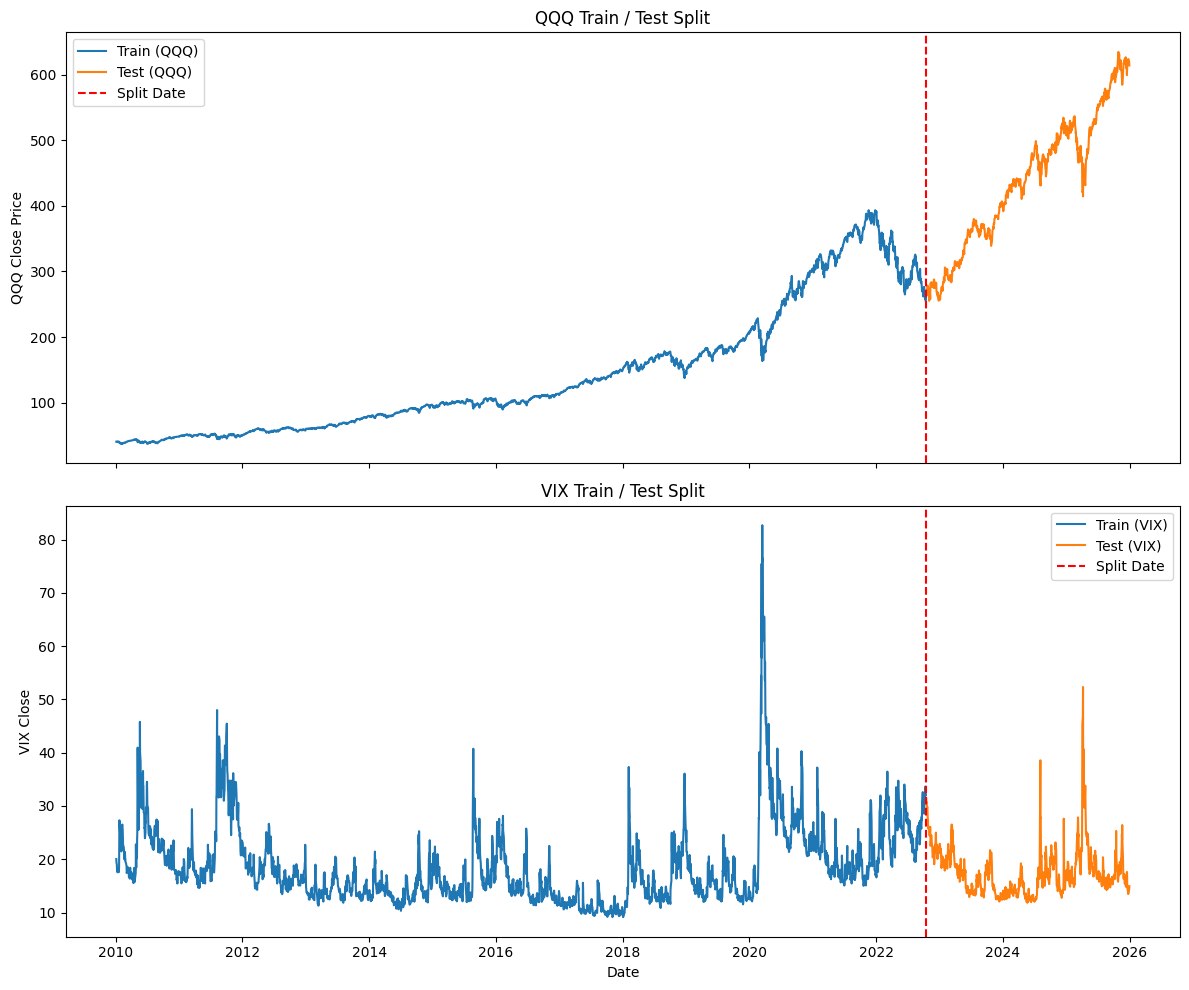

In [5]:
split_ratio = 0.8
split_idx = int(len(df_combined) * split_ratio)


train_df = df_combined.iloc[:split_idx]
test_df  = df_combined.iloc[split_idx:]


split_date = test_df['ds'].iloc[0]


print(f"Train: {len(train_df)} days ({train_df['ds'].min().date()} → {train_df['ds'].max().date()})")
print(f"Test : {len(test_df)} days ({test_df['ds'].min().date()}  → {test_df['ds'].max().date()})")


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)


ax1.plot(train_df['ds'], train_df['y'], label="Train (QQQ)")
ax1.plot(test_df['ds'], test_df['y'], label="Test (QQQ)")
ax1.axvline(split_date, color="red", linestyle="--", label="Split Date")
ax1.set_title("QQQ Train / Test Split")
ax1.set_ylabel("QQQ Close Price")
ax1.legend()


ax2.plot(train_df['ds'], train_df['vix'], label="Train (VIX)")
ax2.plot(test_df['ds'], test_df['vix'], label="Test (VIX)")
ax2.axvline(split_date, color="red", linestyle="--", label="Split Date")
ax2.set_title("VIX Train / Test Split")
ax2.set_xlabel("Date")
ax2.set_ylabel("VIX Close")
ax2.legend()

plt.tight_layout()
plt.show()

In [6]:
y_train = train_df['y'].values
y_test  = test_df['y'].values

In [8]:
fred_indicators = {
    "USEPUINDXD": "EPU",
    "UMCSENT": "UMCSENT",
    "ICSA": "JOBLESS",
    "FEDFUNDS": "FEDFUNDS",
    "WLEMUINDXD": "FLOWS",
    "CPIAUCSL": "CPI"
}


macro = pd.DataFrame({
    name: fred.get_series(ticker, observation_start=start_date, observation_end=end_date)
    for ticker, name in fred_indicators.items()
})


macro["inflation_yoy"] = macro["CPI"].pct_change(12) * 100
macro["inflation_yoy_lag1"] = macro["inflation_yoy"].shift(1)


macro.index = pd.to_datetime(macro.index)
macro = macro.sort_index().ffill()

print(macro.head(10))
print(macro.columns)

               EPU  UMCSENT   JOBLESS  FEDFUNDS   FLOWS      CPI  \
2010-01-01  174.55     74.4       NaN      0.11   57.28  217.488   
2010-01-02  119.52     74.4  456000.0      0.11  122.78  217.488   
2010-01-03  216.95     74.4  456000.0      0.11   78.56  217.488   
2010-01-04  150.35     74.4  456000.0      0.11  114.26  217.488   
2010-01-05  151.16     74.4  456000.0      0.11   16.20  217.488   
2010-01-06   95.95     74.4  456000.0      0.11    6.00  217.488   
2010-01-07   92.20     74.4  456000.0      0.11   30.90  217.488   
2010-01-08  141.92     74.4  456000.0      0.11   19.61  217.488   
2010-01-09  192.83     74.4  469000.0      0.11  113.65  217.488   
2010-01-10  192.36     74.4  469000.0      0.11   51.36  217.488   

            inflation_yoy  inflation_yoy_lag1  
2010-01-01            NaN                 NaN  
2010-01-02            NaN                 NaN  
2010-01-03            NaN                 NaN  
2010-01-04            NaN                 NaN  
2010-01-05 

/var/folders/mn/hy84g9197_j0j3cq0ds1y2zm0000gn/T/ipykernel_15701/2152609849.py:17: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  macro["inflation_yoy"] = macro["CPI"].pct_change(12) * 100


# Combine FRED & YF Data

In [9]:

macro_reset = macro.reset_index().rename(columns={'index': 'ds'})

master_df = pd.merge(df_combined, macro_reset, on='ds', how='left')


master_df = master_df.bfill()

print(master_df.head())
print(f"\nFinal Master Shape: {master_df.shape}")
print(f"Columns: {master_df.columns.tolist()}")

#Save the master dataframe to a CSV file for future use
master_df.to_csv("dataframe.csv", index=False)

          ds          y        vix     EPU  UMCSENT   JOBLESS  FEDFUNDS  \
0 2010-01-04  40.341572  20.040001  150.35     74.4  456000.0      0.11   
1 2010-01-05  40.341572  19.350000  151.16     74.4  456000.0      0.11   
2 2010-01-06  40.098244  19.160000   95.95     74.4  456000.0      0.11   
3 2010-01-07  40.124317  19.059999   92.20     74.4  456000.0      0.11   
4 2010-01-08  40.454556  18.129999  141.92     74.4  456000.0      0.11   

    FLOWS      CPI  inflation_yoy  inflation_yoy_lag1  
0  114.26  217.488            0.0                 0.0  
1   16.20  217.488            0.0                 0.0  
2    6.00  217.488            0.0                 0.0  
3   30.90  217.488            0.0                 0.0  
4   19.61  217.488            0.0                 0.0  

Final Master Shape: (4024, 11)
Columns: ['ds', 'y', 'vix', 'EPU', 'UMCSENT', 'JOBLESS', 'FEDFUNDS', 'FLOWS', 'CPI', 'inflation_yoy', 'inflation_yoy_lag1']


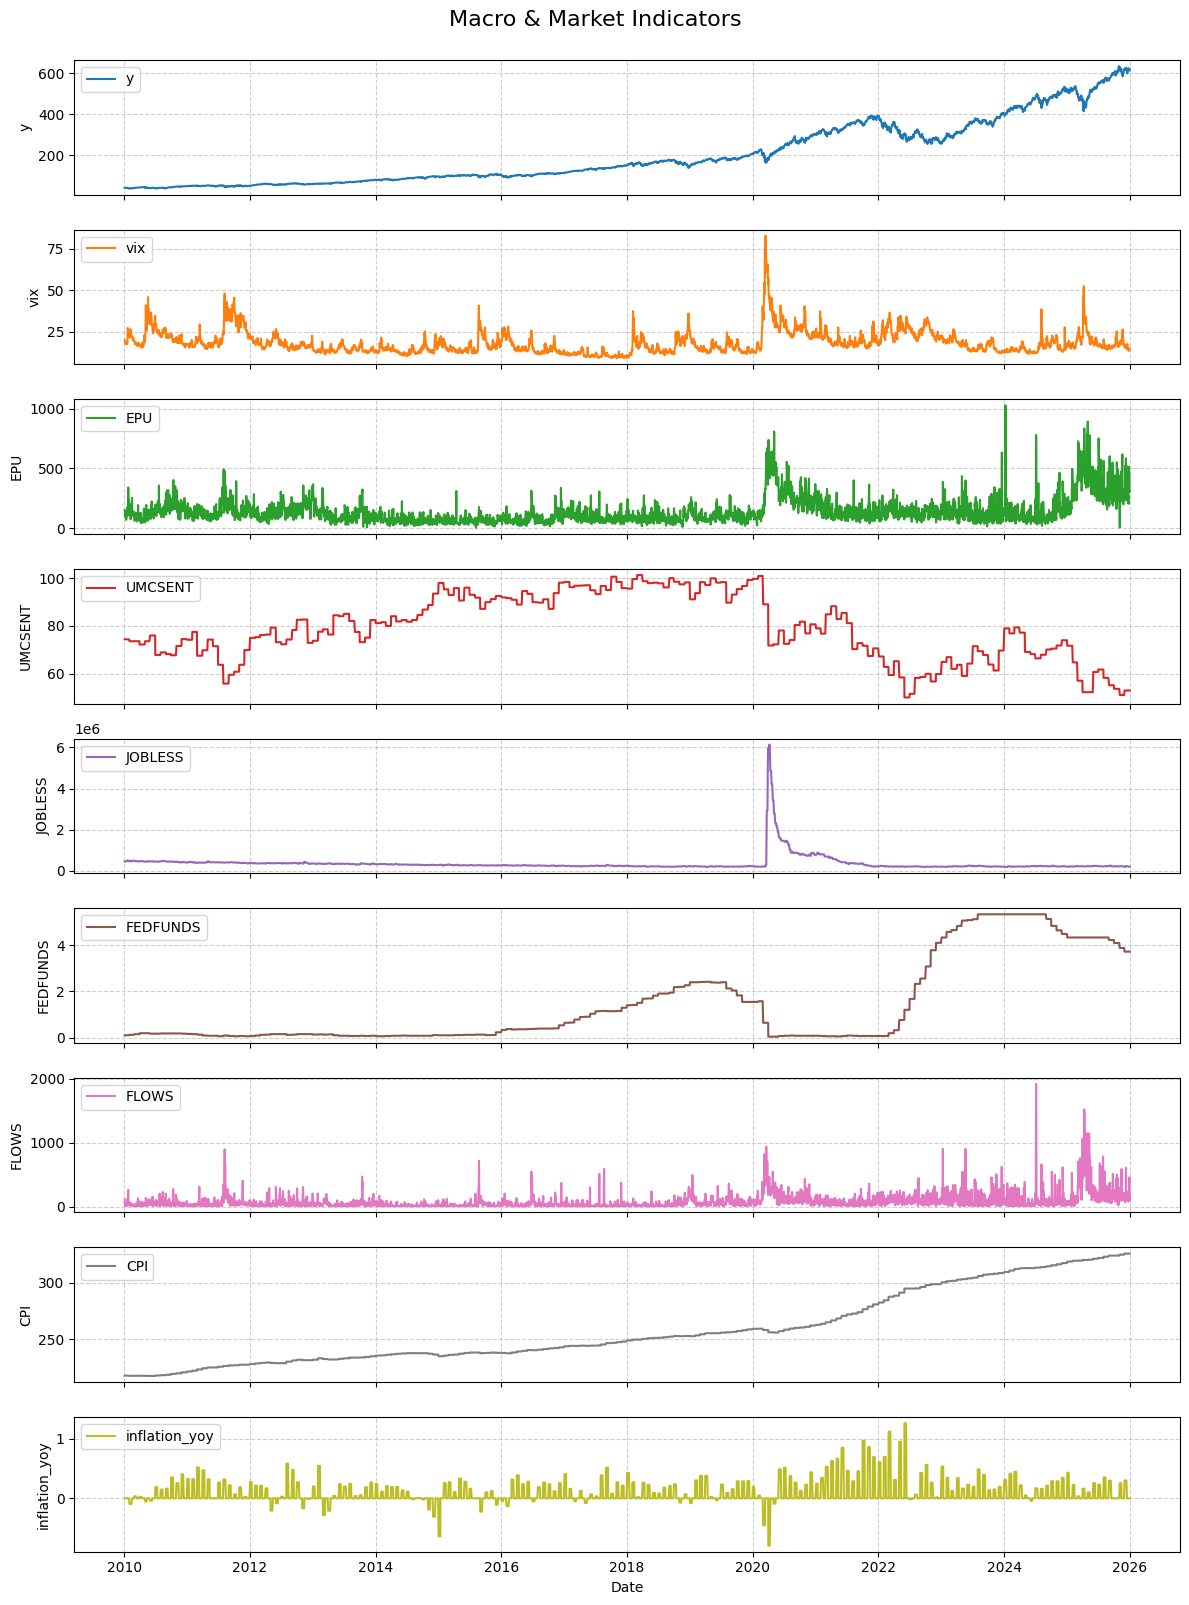

In [10]:
import matplotlib.pyplot as plt


cols_to_plot = [
    'y', 'vix', 'EPU', 'UMCSENT', 'JOBLESS', 
    'FEDFUNDS', 'FLOWS', 'CPI', 'inflation_yoy'
]

fig, axes = plt.subplots(nrows=len(cols_to_plot), ncols=1, figsize=(12, 16), sharex=True)


for i, col in enumerate(cols_to_plot):
    axes[i].plot(master_df['ds'], master_df[col], label=col, color=f'C{i}')
    axes[i].set_ylabel(col)
    
    
    axes[i].grid(True, linestyle='--', alpha=0.6)
    
    axes[i].legend(loc="upper left")

axes[-1].set_xlabel('Date')
fig.suptitle('Macro & Market Indicators', fontsize=16, y=1.0)


plt.tight_layout()
plt.show()